# <center> Math foundations & EDA <center>


This mini‑project explores the link between late‑night doomscrolling and sleep quality using a real dataset. 
 combined descriptive statistics, probability, linear algebra, outlier detection, correlation, and feature engineering to answer one central question:  



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("sleep_doomscrolling_habits.csv")
df

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,D30995,26,85.0,3.56,4,25.4,7.6,34.0,1,169.0,...,Student,India,Tablet,Meditation/Journaling,No,Yes,Yes,Yes,Yes,Poor
996,D30996,23,3.0,1.10,1,10.7,7.5,31.0,1,34.0,...,Student,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Fair
997,D30997,15,28.0,4.38,1,30.6,9.2,20.0,0,100.0,...,Employed Full-time,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
998,D30998,22,23.0,1.84,0,27.9,6.9,41.0,2,45.0,...,Student,India,Tablet,Watching Videos,No,Yes,Yes,Yes,No,Fair


calculated mean, median, mode, std, and IQR for sleep hours, bedtime screen time, and anxiety. Outlier indices were flagged using the IQR rule.  
👉 Sleep hours are fairly symmetric, screen time is skewed by heavy users, and anxiety shows wide spread.


In [10]:


cols=["sleep_hours_per_night","bedtime_screen_time_minutes","anxiety_score"]

for col in cols:
    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()[0]
    std = df[col].std()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].index.tolist()
    
    print(col)
    print("Mean:  ",mean)
    print("Median: ",median)
    print("Mode: ",mode)
    print("Std: ",std)
    print("IQR: ",IQR)
    print("Outlier indices: ",outliers)
    print()

sleep_hours_per_night
Mean:   7.4152000000000005
Median:  7.4
Mode:  7.2
Std:  0.7657514840568937
IQR:  1.0
Outlier indices:  [114, 413, 549, 561, 789, 961]

bedtime_screen_time_minutes
Mean:   50.111
Median:  44.0
Mode:  43.0
Std:  31.328136413312734
IQR:  39.0
Outlier indices:  [33, 41, 42, 49, 88, 136, 139, 219, 235, 285, 308, 532, 537, 609, 621, 683, 700, 746, 778, 857, 882, 889, 961, 982]

anxiety_score
Mean:   4.644
Median:  5.0
Mode:  5
Std:  1.792338270661115
IQR:  3.0
Outlier indices:  []



 compared conditional probabilities:  
- P(Poor | Doomscroller=Yes) vs P(Poor | Doomscroller=No).  
Result: doomscrolling raises the chance of poor sleep quality.  
Bonus: sleep hours histogram looks roughly normal but slightly skewed.


In [13]:
p_poor_yes = df.loc[(df['doomscroller']=="Yes") & (df['sleep_quality_category']=="Poor")].shape[0] / df.loc[df['doomscroller']=="Yes"].shape[0]
p_poor_no  = df.loc[(df['doomscroller']=="No") & (df['sleep_quality_category']=="Poor")].shape[0] / df.loc[df['doomscroller']=="No"].shape[0]

print("P(Poor | Doomscroller=Yes): ",p_poor_yes)
print("P(Poor | Doomscroller=No):  ",p_poor_no)

P(Poor | Doomscroller=Yes):  0.5252100840336135
P(Poor | Doomscroller=No):   0.15267175572519084


In [14]:
if p_poor_yes > p_poor_no:
    print("doomscrolling clearly raises the risk of poor sleep quality.")

doomscrolling clearly raises the risk of poor sleep quality.


 built a simple prediction using bedtime screen time and caffeine intake with made‑up weights.  
👉 Shows how linear algebra underpins prediction, even in a toy example.

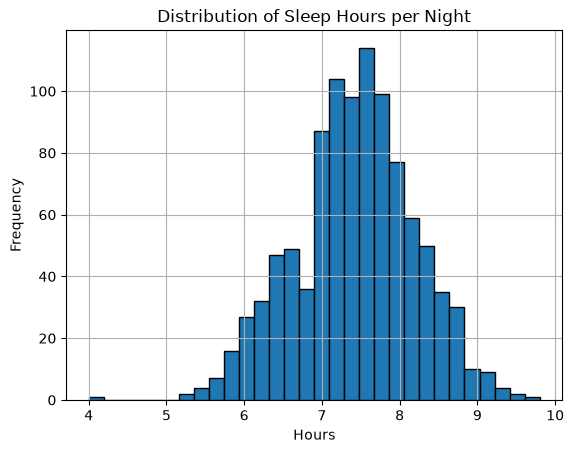

In [18]:
df['sleep_hours_per_night'].hist(bins=30, edgecolor='black')
plt.title("Distribution of Sleep Hours per Night")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

In [23]:
x = df[['bedtime_screen_time_minutes','caffeine_intake_mg_per_day']].values
w=np.array([0.01,.1])
predictions=x@w
print(predictions)

[15.63  9.1   5.41  4.73  8.27  6.91 17.16  5.8  13.47  9.93 15.87  3.03
 15.28  4.19 12.49 17.37 17.48  8.02 22.77 38.22 11.38 12.6   8.39 17.06
 17.98  6.76   nan 12.03 16.91   nan  2.83 17.85 25.11  7.48 11.53 12.39
  8.98  6.34  5.19 22.06  9.53 13.08  3.03  5.28 14.   11.77  9.15  7.25
 12.71 19.82 26.26  8.98 11.22  4.48  1.9   9.71  3.22  5.85  9.61 20.71
  6.3  16.52  8.05 10.36  9.06 30.43 11.45  2.7  20.96  9.21 15.67 22.85
 13.78  6.2  11.22  7.28 44.19 11.37 13.88 11.64  2.39  8.88 11.53 20.7
 15.45 15.98  8.93  4.08  3.28  5.13 22.12 26.21  9.84 28.92  8.79 13.
  8.34  6.   13.37 10.07  5.96 20.59  7.44  3.66 10.28  8.33  4.19 16.44
  1.53  5.64 26.99  6.12 18.97 10.69   nan 18.81  2.28  8.17   nan 11.5
  9.86 13.83  4.32 13.44  3.24 12.91 16.76  9.99  6.9   9.07  8.97  7.99
 31.94 16.19  9.5    nan 21.13 14.11  4.48 26.44  1.78  8.91 13.05 15.49
 23.94 24.16  1.82 10.51 22.36  7.91   nan 10.76 16.74  4.05  6.96 15.23
 37.92  4.31  9.48  7.61  3.94 10.44  2.57  4.11 15.4  

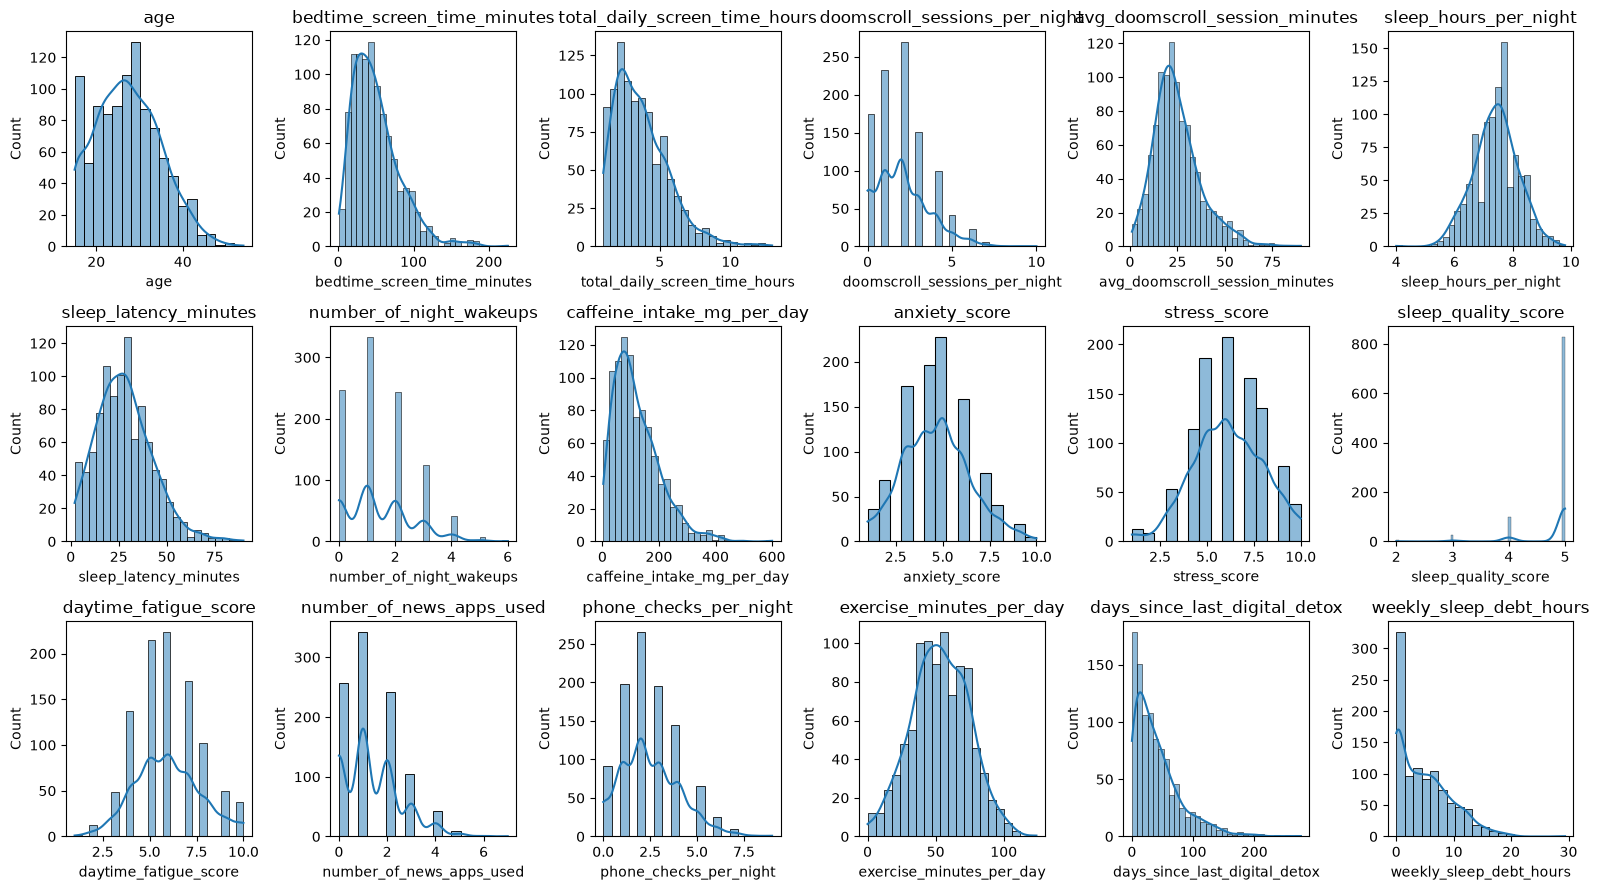

In [26]:
numeric_columns = ["age","bedtime_screen_time_minutes",
"total_daily_screen_time_hours","doomscroll_sessions_per_night","avg_doomscroll_session_minutes",
"sleep_hours_per_night","sleep_latency_minutes","number_of_night_wakeups","caffeine_intake_mg_per_day",
"anxiety_score","stress_score","sleep_quality_score","daytime_fatigue_score","number_of_news_apps_used",
"phone_checks_per_night","exercise_minutes_per_day","days_since_last_digital_detox","weekly_sleep_debt_hours"]

n_cols = 6
n_rows = -(-len(numeric_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.histplot(df, x=col, ax=ax,kde=True)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()

Applied IQR across all numeric columns. Outliers represent extreme but real behaviors (e.g., >150 min screen time, >400 mg caffeine).  
👉  keep them for analysis instead of dropping.

In [27]:
def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]

for cols in numeric_columns:
    found = find_outliers_iqr(df, cols)
    print(f"{cols}: {len(found)} outlier(s) found")
    if len(found) > 0:3333
    print(found[[cols]].to_string())
    print()

age: 3 outlier(s) found
     age
173   50
274   50
704   54

bedtime_screen_time_minutes: 24 outlier(s) found
     bedtime_screen_time_minutes
33                         128.0
41                         158.0
42                         173.0
49                         152.0
88                         128.0
136                        143.0
139                        184.0
219                        161.0
235                        171.0
285                        125.0
308                        148.0
532                        172.0
537                        184.0
609                        127.0
621                        171.0
683                        149.0
700                        149.0
746                        128.0
778                        183.0
857                        128.0
882                        147.0
889                        152.0
961                        225.0
982                        162.0

total_daily_screen_time_hours: 20 outlier(s) found
     total_da

Scatterplots and boxplots show clear links:  
- More screen time → fewer sleep hours.  
- Doomscrolling → longer sleep latency and lower quality.  
- Anxiety and stress → poorer sleep outcomes.

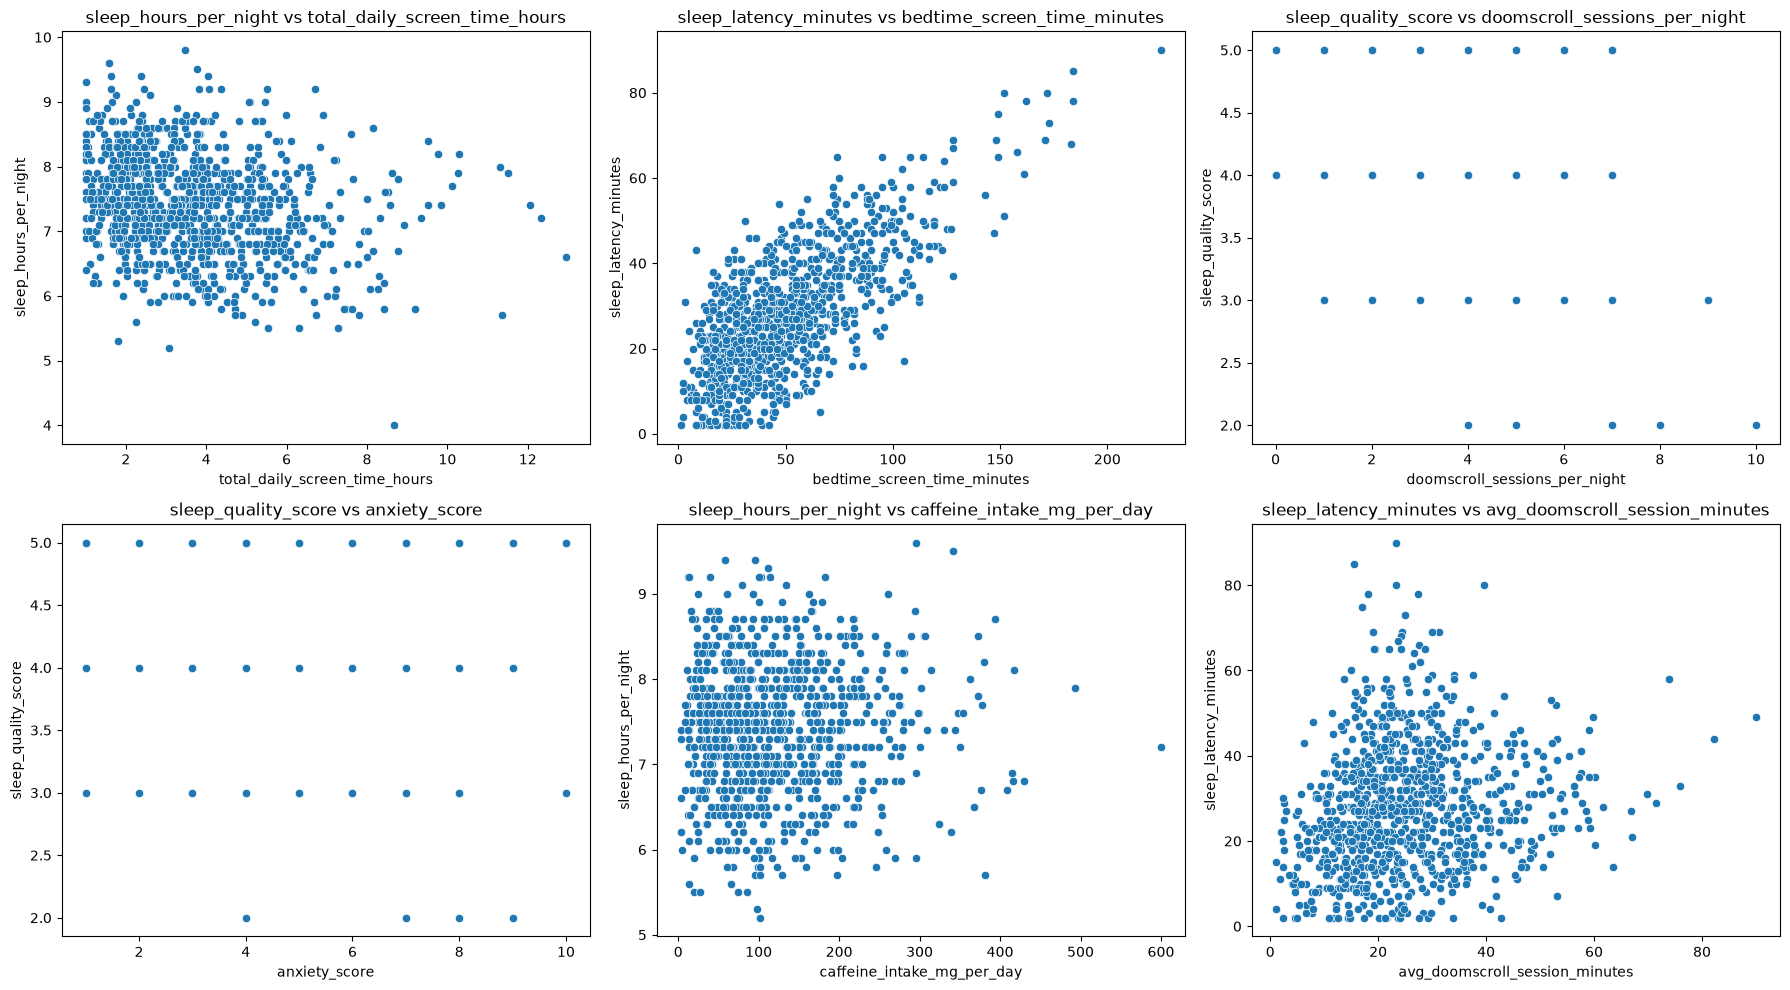

In [29]:
important_pairs = [
    ('total_daily_screen_time_hours', 'sleep_hours_per_night'),
    ('bedtime_screen_time_minutes', 'sleep_latency_minutes'),
    ('doomscroll_sessions_per_night', 'sleep_quality_score'),
    ('anxiety_score', 'sleep_quality_score'),
    ('caffeine_intake_mg_per_day', 'sleep_hours_per_night'),
    ('avg_doomscroll_session_minutes', 'sleep_latency_minutes')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (x, y) in enumerate(important_pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=axes[i])
    axes[i].set_title(f"{y} vs {x}")
plt.tight_layout()
plt.show()

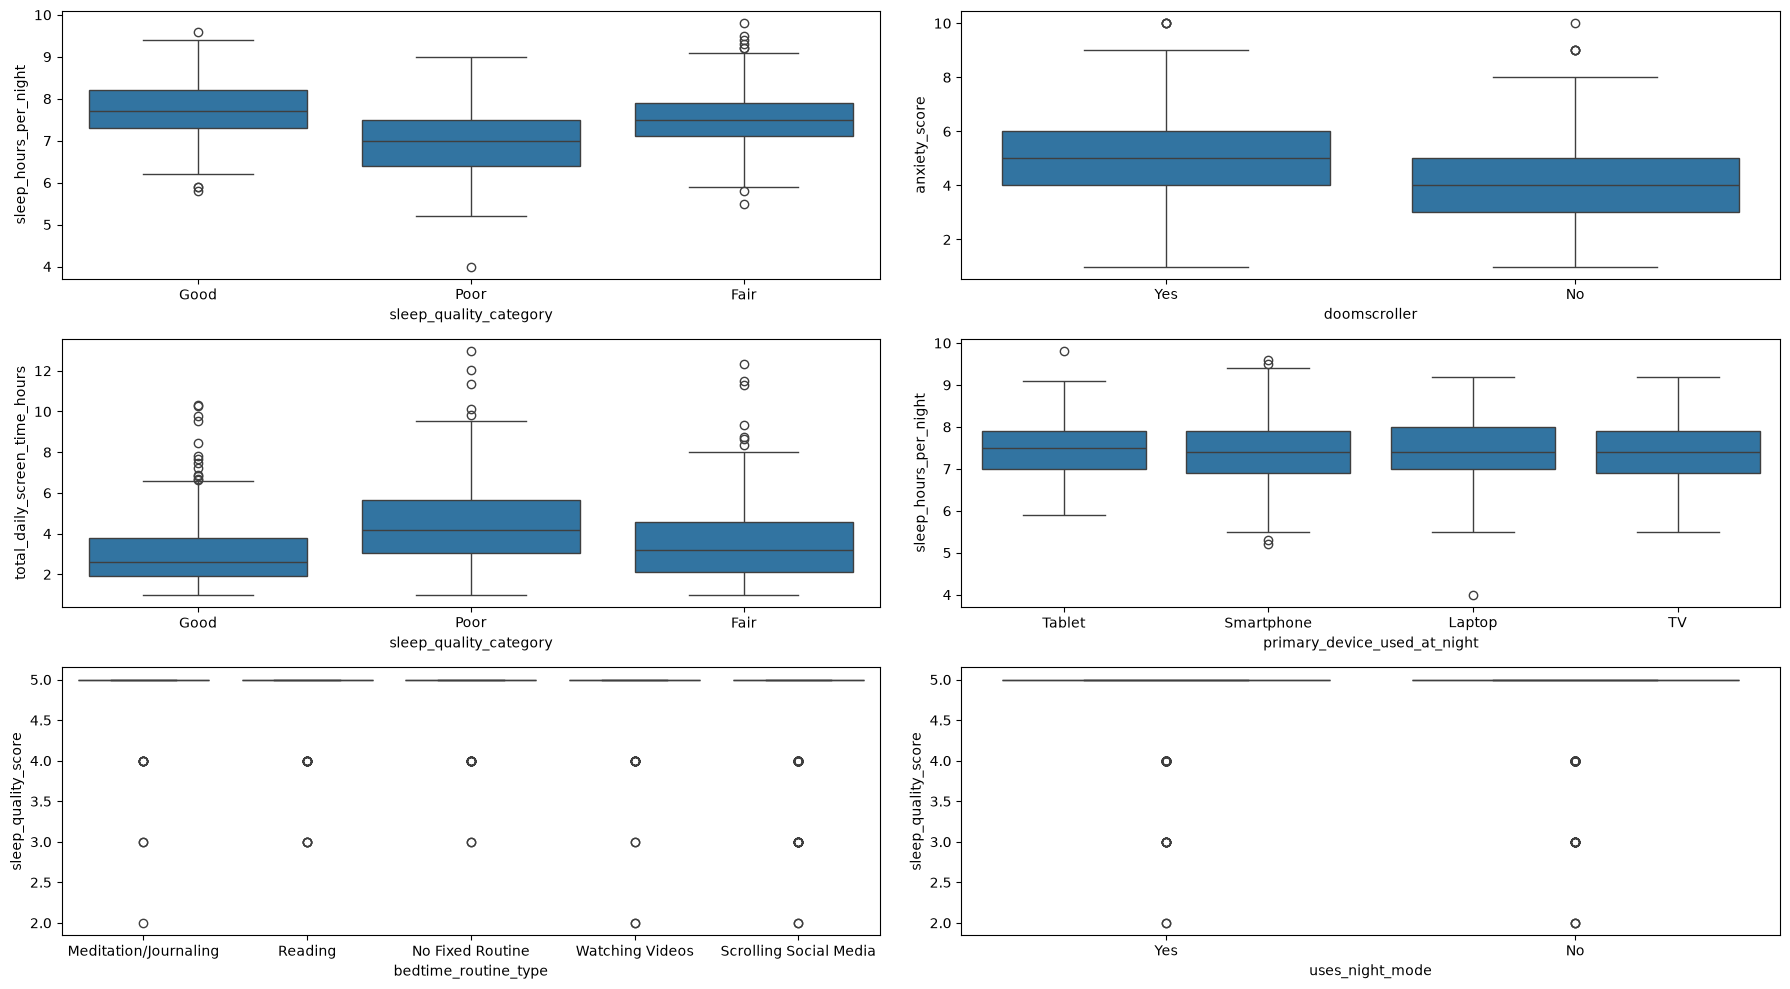

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
axes = axes.flatten()

sns.boxplot(data=df, x='sleep_quality_category', y='sleep_hours_per_night', ax=axes[0])
sns.boxplot(data=df, x='doomscroller', y='anxiety_score', ax=axes[1])
sns.boxplot(data=df, x='sleep_quality_category', y='total_daily_screen_time_hours', ax=axes[2])
sns.boxplot(data=df, x='primary_device_used_at_night', y='sleep_hours_per_night', ax=axes[3])
sns.boxplot(data=df, x='bedtime_routine_type', y='sleep_quality_score', ax=axes[4])
sns.boxplot(data=df, x='uses_night_mode', y='sleep_quality_score', ax=axes[5])

plt.tight_layout()
plt.show()

Heatmap confirms strong relationships:  
- Doomscrolling ↔ bedtime screen time (r ≈ 0.79).  
- Phone checks ↔ night wakeups (r ≈ 0.76).  
- Screen time ↔ sleep latency (r ≈ 0.73).  
👉 Digital habits and psychological stress are tightly tied to sleep disruption.

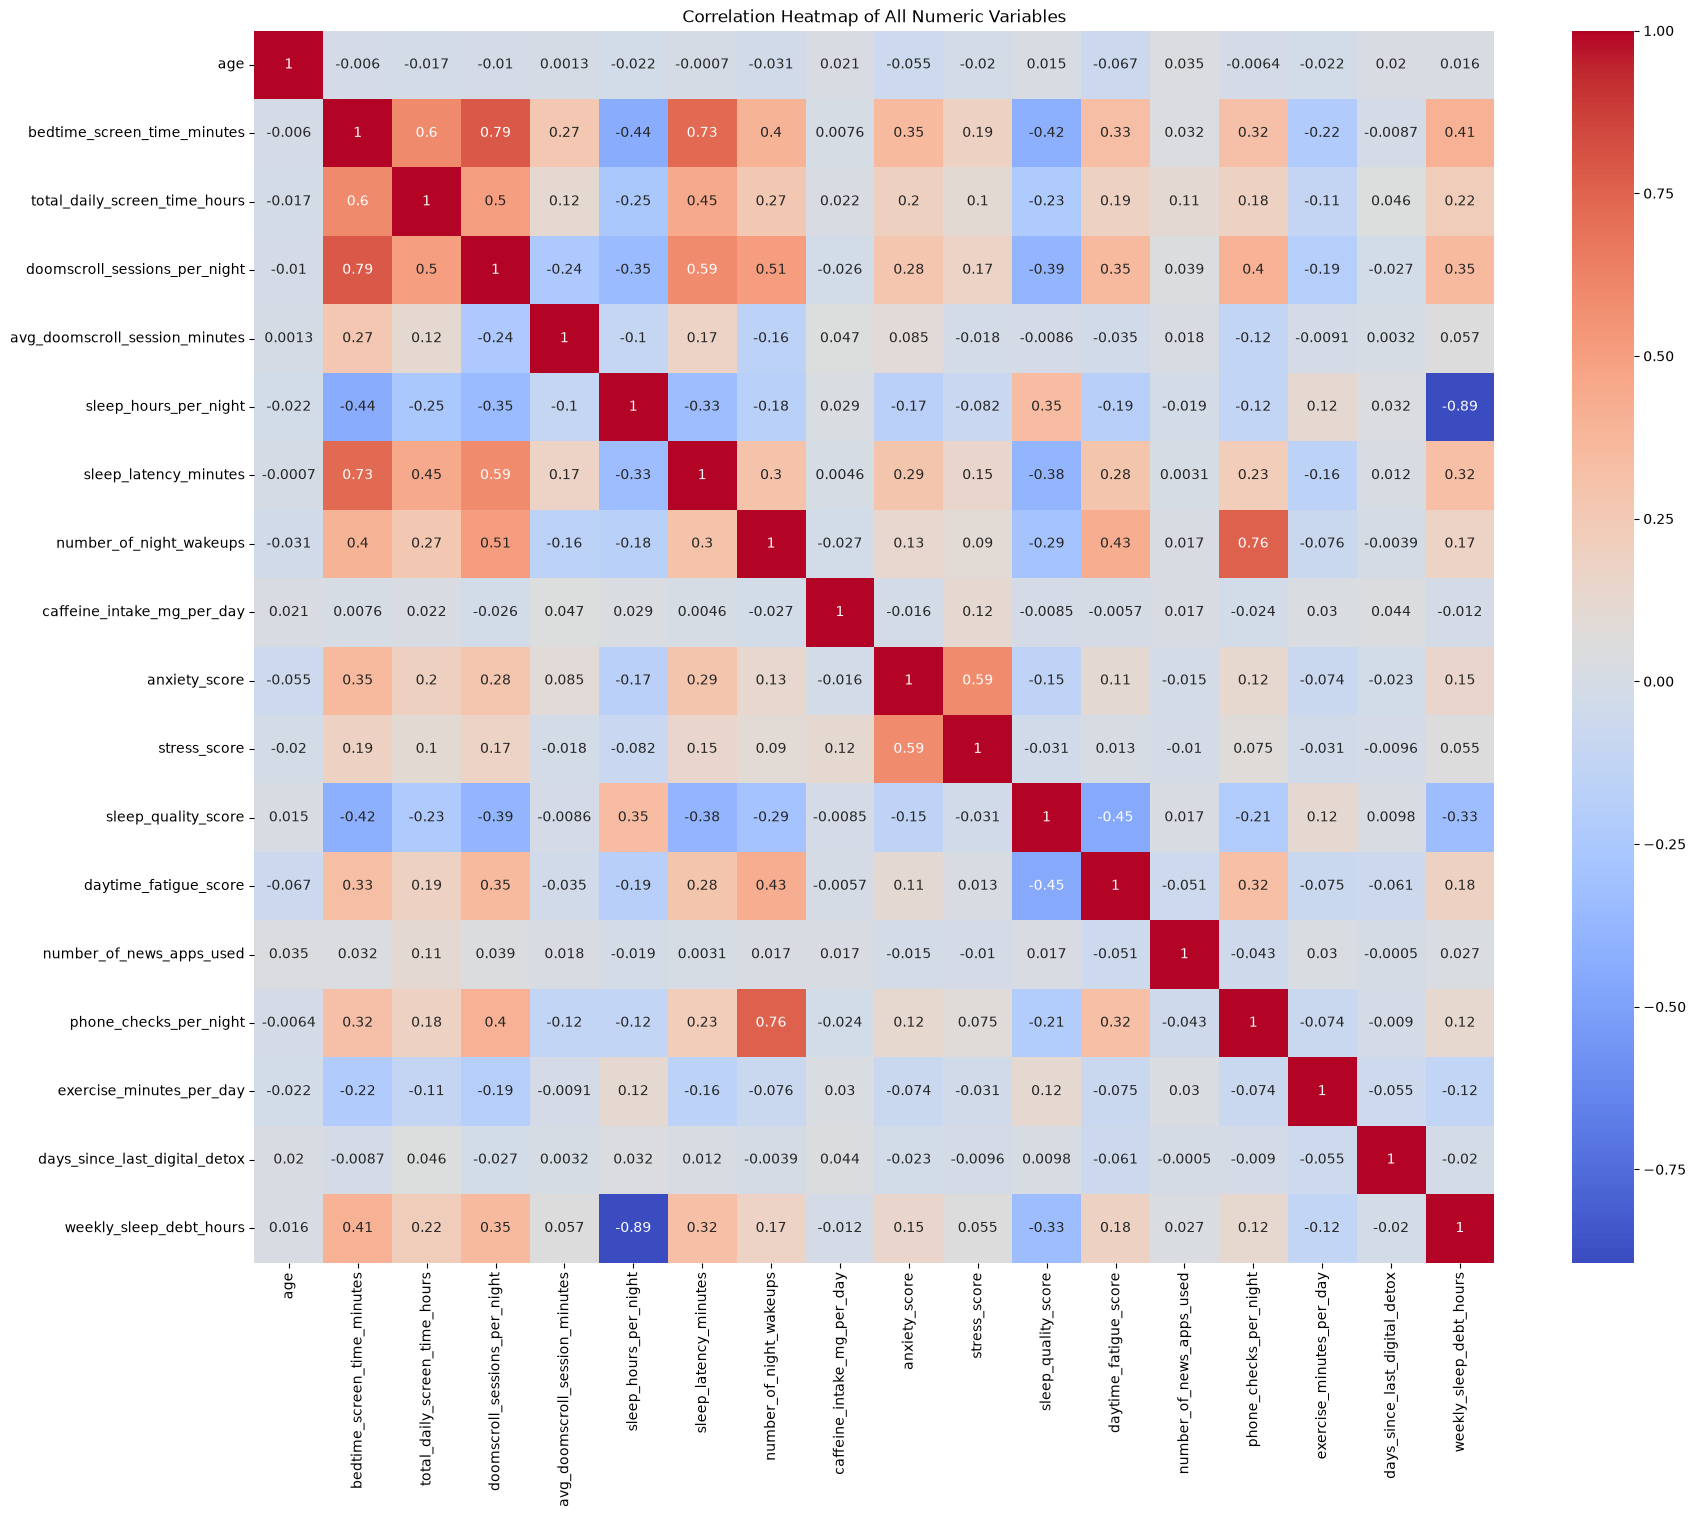

In [28]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of All Numeric Variables")
plt.show()

In [31]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
top_correlations = corr_pairs.head(5)
print("Top 5 Strongest Correlations:")
print(top_correlations)



Top 5 Strongest Correlations:
doomscroll_sessions_per_night  bedtime_screen_time_minutes      0.787583
bedtime_screen_time_minutes    doomscroll_sessions_per_night    0.787583
number_of_night_wakeups        phone_checks_per_night           0.758347
phone_checks_per_night         number_of_night_wakeups          0.758347
bedtime_screen_time_minutes    sleep_latency_minutes            0.729464
dtype: float64



Created new features:  
- `doomscroll_time_total`  
- `sleep_efficiency`  
- `screen_time_ratio`  
👉 These engineered metrics capture behavior intensity and sleep efficiency.


In [36]:
doomscroll_time_total = df["doomscroll_sessions_per_night"] * df["avg_doomscroll_session_minutes"]
sleep_efficiency = df["sleep_hours_per_night"] / (df["sleep_latency_minutes"] + df["sleep_hours_per_night"])
screen_time_ratio = df["bedtime_screen_time_minutes"] / (df["total_daily_screen_time_hours"]*60)

print("doomscroll_time_total: ",doomscroll_time_total)
print("sleep_fficiency: ",sleep_efficiency)
print("screen_time_ratio: ",screen_time_ratio)


doomscroll_time_total:  0       10.8
1       88.8
2       46.5
3        0.0
4       64.4
       ...  
995    101.6
996     10.7
997     30.6
998      0.0
999     32.4
Length: 1000, dtype: float64
sleep_fficiency:  0      0.298893
1      0.184211
2      0.228296
3      0.193548
4      0.274809
         ...   
995    0.182692
996    0.194805
997    0.315068
998    0.144050
999    0.217391
Length: 1000, dtype: float64
screen_time_ratio:  0      0.117117
1      0.415512
2      0.165049
3      0.236185
4      0.183361
         ...   
995    0.397940
996    0.045455
997    0.106545
998    0.208333
999    0.351406
Length: 1000, dtype: float64


### 📖 Summary
Across all steps, the evidence is consistent: doomscrolling and heavy screen use delay sleep, reduce sleep hours, and worsen sleep quality. Anxiety and stress amplify fatigue. Outliers highlight extreme but real cases. Overall, the project supports the hypothesis: **doomscrolling really does wreck your sleep.**